<a href="https://colab.research.google.com/github/disCrybee/Machine-Learning/blob/main/%D0%9B%D0%912_%D0%9F%D0%B5%D1%80%D0%B5%D1%85%D1%80%D0%B5%D1%81%D1%82_3_9_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Прізвище, група

---



# Завдання 1



Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [1]:
import requests
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_2207/2099464608.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [2]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [4]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [5]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [6]:
#Convert columns to float type
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['United Nations (2024)'] = pd.to_numeric(df['United Nations (2024)'], errors='coerce')

In [7]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [8]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [9]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


5. Ще раз вивести датасет

In [10]:
df.tail()

,Country,IMF (2026),World Bank (2025),United Nations (2024)
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0
221,Tuvalu,65.0,57.0,56.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [11]:
#Check for duplicates and drop them
df.duplicated().sum()

np.int64(0)

In [12]:
#df.drop_duplicates(inspace=True)

7.	Вивести описову статистику датасету describe()

In [13]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,1.910000e+02,1.870000e+02,2.130000e+02
mean,1.319229e+06,1.255590e+06,1.043818e+06
std,9.532709e+06,9.034696e+06,7.994824e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.560750e+04,1.561900e+04,8.549000e+03
50%,5.422800e+04,5.206100e+04,3.709400e+04
75%,3.689105e+05,3.259470e+05,2.571450e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [14]:
# Count difference between. IMF_Forecast and WB_Estimate for each country
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

# Find which country hasthe largest difference between IMF and wB
max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.head(10)

World has the largest difference between IMF and WB: 7945165.0


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
0,World,126295331.0,118350166.0,111565144.0,7945165.0
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [15]:
# Calculate correlation between IMF and WB and UN
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9999856112426755
Correlation between IMF and UN: 0.9999661976487624
Correlation between WB and UN: 0.9999815753893803


In [16]:
# Find highest correlation
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
  print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
  print('IMF and UN have the highest correlation')
else:
  print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [17]:
# Find mean of IMF, WB and UN
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(1319229.2460732984)

In [18]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(1255590.4224598932)

In [19]:
mean_UN = df['United Nations (2024)'] .mean()
mean_UN

np.float64(1043818.2159624413)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [20]:
# Find standard deviation for each row
df['std'] = df.iloc[:, 1:].std(axis=1)

# Find country with the highest standard deviation
max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

World has the highest standard deviation: 55721978.507490404


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
0,World,126295331.0,118350166.0,111565144.0,7945165.0,5.572198e+07
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [21]:
# Find max and min GDP for each year
max_IMF = df['IMF (2026)'].max(); min_IMF = df['IMF (2026)'].min()
max_WB = df['World Bank (2025)'].max(); min_WB = df['World Bank (2025)'].min()
max_UN = df['United Nations (2024)'].max(); min_UN = df['United Nations (2024)'].min()

print(f'Max IMF: (max_IMF), Min IMF: (min_IMF)')
print(f'Max WB: (max WB), Min WB: (min WB)')
print(f'Max UN: (max_UN), Min UN: (min_UN)')

Max IMF: (max_IMF), Min IMF: (min_IMF)
Max WB: (max WB), Min WB: (min WB)
Max UN: (max_UN), Min UN: (min_UN)


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

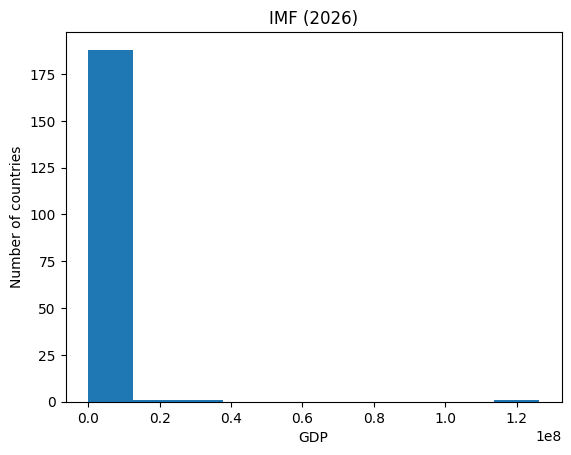

In [22]:
import matplotlib.pyplot as plt

#Build a histogram of IMF_Forecast
plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [23]:
# Calculate share of world GDP for each country for each year
df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
df['UN_Share'] = df['United Nations (2024)'] / df['United Nations (2024)']. sum()
df.head(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
0,World,126295331.0,118350166.0,111565144.0,7945165.0,5.572198e+07,0.501226,0.504057,0.501792
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.128521,0.131049,0.131775
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.082753,0.083043,0.084305
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.021641,0.021512,0.020959
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.017380,0.018889,0.018109
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.016926,0.017047,0.016578
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.016483,0.016849,0.017776
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.014272,0.014337,0.014215
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.010867,0.010867,0.010708
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.010543,0.010909,0.009775


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

<Axes: title={'center': 'Динаміка макроекономічних показників'}>

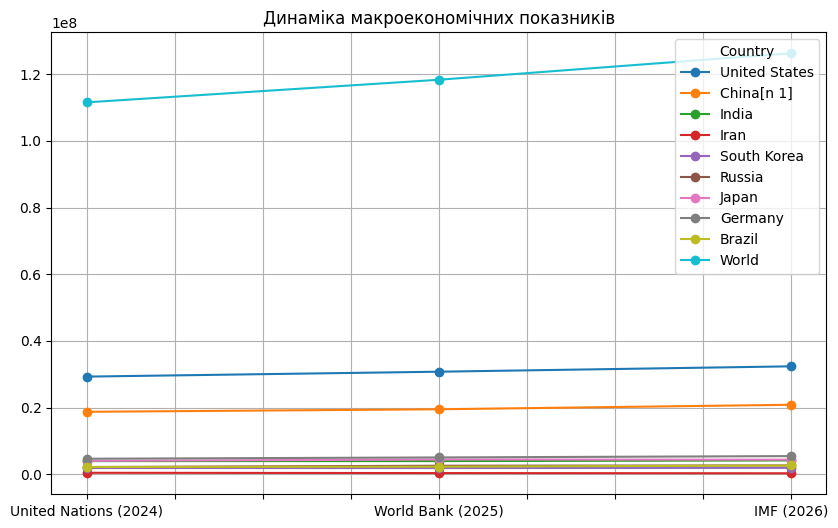

In [24]:
# Find top 10 countries with the most significant change in share of world GDP between IMF and UN
df['IMF_UN_Diff'] = abs(df['IMF_Share'] - df['UN_Share'])
df_top10 = df.nlargest(10, 'IMF_UN_Diff')
df_top10
# Формуємо таблицю лише з необхідними даними та встановлюємо країни як індекси
df_plot = df_top10.set_index('Country')[['United Nations (2024)', 'World Bank (2025)', 'IMF (2026)']]
# Транспонуємо матрицю (.T) та викликаємо побудову графіка одним рядком
df_plot.T.plot(kind='line', marker='o', figsize=(10, 6), grid=True, title='Динаміка макроекономічних показників')

Загалом можна побачити, що частка ВВП в світовій економіці залишається досить стабільною, що навіть найбільша зміна все ще у межах десятиної частини відсотку.

Загалом можна побачити, що частка ВВП в світовій економіці залишається досить стабільною, що навіть найбільша зміна все ще у межах десятиної частини відсотку.


Загалом можна побачити, що частка ВВП в світовій економіці залишається досить стабільною, що навіть найбільша зміна все ще у межах десятиної частини відсотку.